In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
! kaggle datasets download -d quadeer15sh/augmented-forest-segmentation

Dataset URL: https://www.kaggle.com/datasets/quadeer15sh/augmented-forest-segmentation
License(s): other
100% 172M/172M [00:09<00:00, 23.7MB/s]
100% 172M/172M [00:09<00:00, 19.7MB/s]


In [5]:
! unzip augmented-forest-segmentation.zip

Streaming output truncated to the last 5000 lines.
  inflating: Forest Segmented/Forest Segmented/masks/119079_mask_73.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/119079_mask_77.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/119079_mask_78.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/119079_mask_80.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/119079_mask_81.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/119079_mask_87.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/119079_mask_88.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/122104_mask_00.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/122104_mask_01.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/122104_mask_03.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/122104_mask_04.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/122104_mask_11.jpg  
  inflating: Forest Segmented/Forest Segmented/masks/122104_m

In [6]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import albumentations as A
import numpy as np
import tensorflow as tf
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

def create_dir(path):
    """ Create a directory. """
    if not os.path.exists(path):
        os.makedirs(path)

def load_data(path, split=0.2):
    """ Load the images and masks """
    images = sorted(glob(f"{path}/images/*.jpg"))
    masks = sorted(glob(f"{path}/masks/*.jpg"))

    """ Split the data """
    split_size = int(len(images) * split)
    train_x, test_x = train_test_split(images, test_size=split_size, random_state=42)
    train_y, test_y = train_test_split(masks, test_size=split_size, random_state=42)

    split_size = int(len(train_x) * split)
    train_x, valid_x = train_test_split(train_x, test_size=split_size, random_state=42)
    train_y, valid_y = train_test_split(train_y, test_size=split_size, random_state=42)

    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y)


def augment_data(images, masks, save_path, augment=True):
    """ Performing data augmentation. """
    H = 256
    W = 256

    augmentation_pipeline = A.Compose([

            A.HorizontalFlip(p=0.6),

            A.VerticalFlip(p=0.6),

            A.Rotate(limit=30, p=0.6),

            A.ElasticTransform(alpha=30, sigma=50, p=0.6),

            A.GaussianBlur(blur_limit=(7, 13), p=0.6),

            A.CoarseDropout(max_holes=256, max_height=8, max_width=8, min_holes=128, min_height=4, min_width=4, p=0.6),

            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=0, border_mode=cv2.BORDER_CONSTANT, p=0.6),

            A.ShiftScaleRotate(shift_limit=0, scale_limit=0.1, rotate_limit=0, border_mode=cv2.BORDER_CONSTANT, p=0.6)

        ])

    for idx, (x, y) in tqdm(enumerate(zip(images, masks)), total=len(images)):
        """ Extracting the dir name and image name """
        dir_name = x.split("/")[-3]
        name = dir_name + "_" + x.split("/")[-1].split(".")[0]

        """ Read the image and mask """
        x = cv2.imread(x, cv2.IMREAD_COLOR)
        y = cv2.imread(y, cv2.IMREAD_COLOR)



        X = [x]
        Y = [y]

        if augment == True:
          for _ in range(1):
            augmented = augmentation_pipeline(image=x,mask=y)
            X.append(augmented["image"])
            Y.append(augmented["mask"])

          aug = A.HorizontalFlip(p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])

          aug = A.VerticalFlip(p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])

          aug = A.Rotate(limit=(15,45), border_mode=cv2.BORDER_CONSTANT, p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])

          aug = A.ElasticTransform(alpha=60, sigma=100, p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])

          aug = A.GaussianBlur(blur_limit=(7, 13), p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])

          aug = A.CoarseDropout(max_holes=256, max_height=8, max_width=8, min_holes=128, min_height=4, min_width=4, p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])

          aug = A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=0, border_mode=cv2.BORDER_CONSTANT, p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])

          aug = A.ShiftScaleRotate(shift_limit=0, scale_limit=0.1, rotate_limit=0, border_mode=cv2.BORDER_CONSTANT, p=1)
          augmented = aug(image=x, mask=y)
          X.append(augmented["image"])
          Y.append(augmented["mask"])


        idx = 0
        for i, m in zip(X, Y):
            i = cv2.resize(i, (W, H))
            m = cv2.resize(m, (W, H))
            m = m/255.0
            m = (m > 0.5) * 255

            if len(X) == 1:  # each loop it will take one image
                tmp_image_name = f"{name}.jpg"
                tmp_mask_name  = f"{name}.jpg"
            else:
                tmp_image_name = f"{name}_{idx}.jpg"
                tmp_mask_name  = f"{name}_{idx}.jpg"

            image_path = os.path.join(save_path, "image/", tmp_image_name)
            mask_path  = os.path.join(save_path, "mask/", tmp_mask_name)

            cv2.imwrite(image_path, i)
            cv2.imwrite(mask_path, m)

            idx = idx + 1
        #break


if __name__ == "__main__":
    """ Load the dataset """
    dataset_path = os.path.join("Forest Segmented/Forest Segmented", "")
    (train_x, train_y), (valid_x, valid_y), (test_x, test_y)  = load_data(dataset_path, split=0.2)

    print("Train: ", len(train_x))
    print("Valid: ", len(valid_x))
    print("Test: ", len(test_x))

    create_dir("new_data/train/image/")
    create_dir("new_data/train/mask/")
    create_dir("new_data/valid/image/")
    create_dir("new_data/valid/mask/")
    create_dir("new_data/test/image/")
    create_dir("new_data/test/mask/")

    augment_data(train_x, train_y, "new_data/train/", augment=True)
    augment_data(valid_x, valid_y, "new_data/valid/", augment=False)
    augment_data(test_x, test_y, "new_data/test/", augment=False)

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Train:  3270
Valid:  817
Test:  1021


100%|██████████| 1021/1021 [00:02<00:00, 356.53it/s]


In [7]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input, Add, Dropout
from tensorflow.keras.models import Model

def vanilla_conv_block(input, num_filters, dropout_rate=0.0):
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    return x

def residual_conv_block(input, num_filters, dropout_rate=0.0):
    # First conv block
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    # Second conv block
    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Residual connection
    r = Conv2D(num_filters, 1, padding="same")(input)  # 1x1 conv to match dimensions
    x = Add()([x, r])  # Add residual connection
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    return x

def encoder_block(input, num_filters, use_residual=True, dropout_rate=0.0):
    if use_residual:
        x = residual_conv_block(input, num_filters, dropout_rate)
    else:
        x = vanilla_conv_block(input, num_filters, dropout_rate)
    p = MaxPool2D((2, 2))(x)
    return x, p

def decoder_block(input, skip_features, num_filters, dropout_rate=0.0):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = Concatenate()([x, skip_features])
    x = residual_conv_block(x, num_filters, dropout_rate)
    return x

def build_hybrid_residual_unet(input_shape):
    inputs = Input(input_shape)

    # Encoder - first block is vanilla, rest are residual
    s1, p1 = encoder_block(inputs, 16, use_residual=False)  # Vanilla conv block
    #s2, p2 = encoder_block(p1, 16, use_residual=True)      # Residual blocks
    s2, p2 = encoder_block(p1, 32, use_residual=True)
    #s4, p4 = encoder_block(p3, 32, use_residual=True)
    s3, p3 = encoder_block(p2, 64, use_residual=True, dropout_rate = 0.2)

    # Bridge
    b1 = residual_conv_block(p3, 64, dropout_rate = 0.2)

    # Decoder - all blocks are residual
    d1 = decoder_block(b1, s3, 64, dropout_rate = 0.2)
    #d2 = decoder_block(d1, s4, 32)
    d2 = decoder_block(d1, s2, 32)
    #d4 = decoder_block(d3, s2, 16)
    d3 = decoder_block(d2, s1, 16)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d3)

    model = Model(inputs, outputs, name="Hybrid-Residual-U-Net")
    return model

if __name__ == "__main__":
    input_shape = (256, 256, 3)
    model = build_hybrid_residual_unet(input_shape)
    model.summary()

Model: "Hybrid-Residual-U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 256, 256, 16)   │            448 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 256, 256, 16)   │             64 │ conv2d_21[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_14             │ (None, 256, 256, 16)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_20 (Dropout)      │ (None, 256, 256, 16)   │              0 │ activation_14[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 256, 256, 16)   │          2,320 │ dropout_20[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 256, 256, 16)   │             64 │ conv2d_22[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_15             │ (None, 256, 256, 16)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_21 (Dropout)      │ (None, 256, 256, 16)   │              0 │ activation_15[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 128, 128, 16)   │              0 │ dropout_21[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 128, 128, 32)   │            128 │ conv2d_23[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_16             │ (None, 128, 128, 32)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_22 (Dropout)      │ (None, 128, 128, 32)   │              0 │ activation_16[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 128, 128, 32)   │          9,248 │ dropout_22[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1

 Total params: 338,049 (1.29 MB)

 Trainable params: 336,897 (1.29 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K

def iou(y_true, y_pred):
    """Calculate IOU using pure TensorFlow operations"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten the tensors
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    # Add smooth factor to avoid division by zero
    iou_score = (intersection + 1e-15) / (union + 1e-15)
    return iou_score


smooth = 1e-15
def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import cv2
from glob import glob
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision, Accuracy
#from model import unet
#from metrics import dice_loss, dice_coef, iou

H = 256
W = 256

def create_dir(path):
    """ Create a directory. """
    if not os.path.exists(path):
        os.makedirs(path)

def shuffling(x, y):
    x, y = shuffle(x, y, random_state=42)
    return x, y

def load_data(path):
    x = sorted(glob(os.path.join(path, "image", "*.jpg")))
    y = sorted(glob(os.path.join(path, "mask", "*.jpg")))
    return x, y

def read_image(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = x/255.0
    x = x.astype(np.float32)
    return x

def read_mask(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = x/255.0
    x = x > 0.5
    x = x.astype(np.float32)
    x = np.expand_dims(x, axis=-1)
    return x

def tf_parse(x, y):
    def _parse(x, y):
        x = read_image(x)
        y = read_mask(y)
        return x, y

    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32])
    x.set_shape([H, W, 3])
    y.set_shape([H, W, 1])
    return x, y

def tf_dataset(x, y, batch=8):
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    dataset = dataset.map(tf_parse)
    dataset = dataset.batch(batch)
    dataset = dataset.prefetch(10)
    return dataset


if __name__ == "__main__":
    """ Seeding """
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)

    """ Directory for storing files """
    create_dir("files")

    """ Hyperparameters """
    batch_size = 16
    lr = 1e-3
    num_epochs = 20
    model_path = os.path.join("files", "model.keras")
    csv_path = os.path.join("files", "data.csv")

    """ Dataset """
    dataset_path = os.path.join("new_data")
    train_path = os.path.join(dataset_path, "train")
    valid_path = os.path.join(dataset_path, "valid")

    train_x, train_y = load_data(train_path)
    train_x, train_y = shuffling(train_x, train_y)
    valid_x, valid_y = load_data(valid_path)

    print(f"Train: {len(train_x)} - {len(train_y)}")
    print(f"Valid: {len(valid_x)} - {len(valid_y)}")

    train_dataset = tf_dataset(train_x, train_y, batch=batch_size)
    valid_dataset = tf_dataset(valid_x, valid_y, batch=batch_size)


    """ Model """
    model = build_hybrid_residual_unet((H, W, 3))
    metrics = [dice_coef, iou, Recall(), Precision(), Accuracy()]
    model.compile(loss=dice_loss, optimizer=Adam(lr), metrics=metrics)

    # Define a learning rate schedule function
    def lr_schedule(epoch, lr):
        initial_lr = 0.001  # Initial learning rate
        drop_factor = 0.8   # Factor by which to drop the learning rate

        return lr * drop_factor


    # Create the LearningRateScheduler callback
    lr_scheduler = LearningRateScheduler(lr_schedule)

    callbacks = [
        ModelCheckpoint(model_path, verbose=1, save_best_only=True),
        lr_scheduler,
        #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        CSVLogger(csv_path),
        TensorBoard(),
        EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True),
    ]

    history = model.fit(
        train_dataset,
        epochs=num_epochs,
        validation_data=valid_dataset,
        callbacks=callbacks,
        shuffle=False
    )

Train: 32700 - 32700
Valid: 817 - 817
Epoch 1/20
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.0204 - dice_coef: 0.8184 - iou: 0.6966 - loss: 0.1816 - precision: 0.7591 - recall: 0.8996
Epoch 1: val_loss improved from inf to 0.24795, saving model to files/model.keras
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 359s 157ms/step - accuracy: 0.0204 - dice_coef: 0.8184 - iou: 0.6966 - loss: 0.1816 - precision: 0.7591 - recall: 0.8996 - val_accuracy: 0.1919 - val_dice_coef: 0.7550 - val_iou: 0.6211 - val_loss: 0.2479 - val_precision: 0.8497 - val_recall: 0.7072 - learning_rate: 8.0000e-04
Epoch 2/20
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.3793 - dice_coef: 0.8445 - iou: 0.7335 - loss: 0.1555 - precision: 0.7936 - recall: 0.9077
Epoch 2: val_loss improved from 0.24795 to 0.15347, saving model to files/model.keras
2044/2044 ━━━━━━━━━━━━━━━━━━━━ 290s 142ms/step - accuracy: 0.3793 - dice_coef: 0.8445 - iou: 0.7335 - loss: 0.1555 - precision: 0.7936 - recall: 0.9077 - val_accur

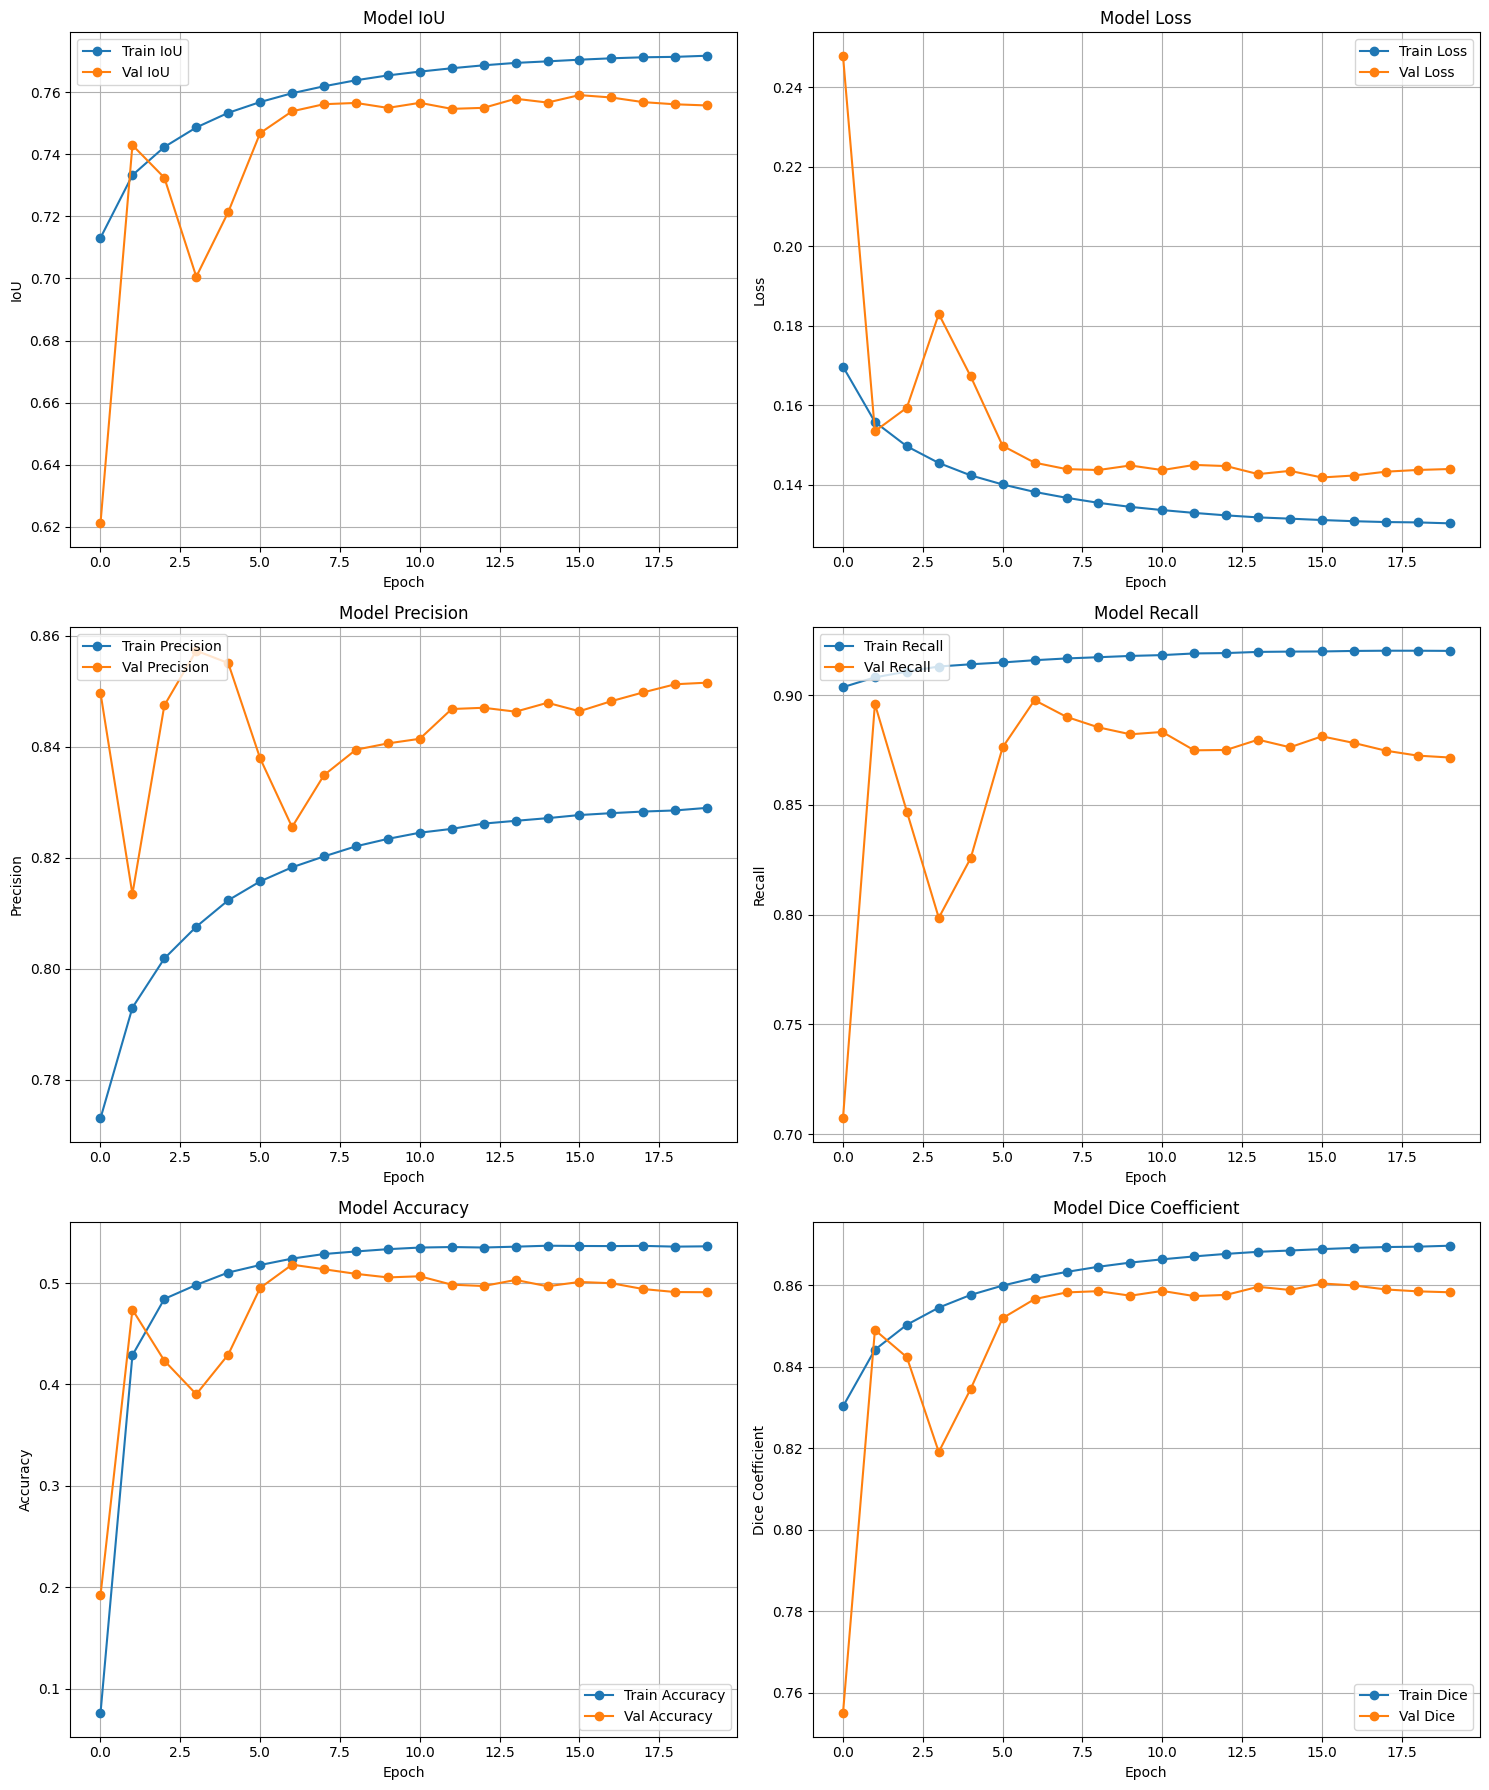

In [10]:
import matplotlib.pyplot as plt

# Define a figure with an appropriate size - now 3x2 layout
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Plot IoU (original)
axes[0, 0].plot(history.history['iou'], label='Train IoU', marker='o')
axes[0, 0].plot(history.history['val_iou'], label='Val IoU', marker='o')
axes[0, 0].set_title('Model IoU')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('IoU')
axes[0, 0].legend(loc='upper left')
axes[0, 0].grid(True)

# Plot Loss (original)
axes[0, 1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0, 1].plot(history.history['val_loss'], label='Val Loss', marker='o')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True)

# Plot Precision (original)
axes[1, 0].plot(history.history['precision'], label='Train Precision', marker='o')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision', marker='o')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend(loc='upper left')
axes[1, 0].grid(True)

# Plot Recall (original)
axes[1, 1].plot(history.history['recall'], label='Train Recall', marker='o')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', marker='o')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend(loc='upper left')
axes[1, 1].grid(True)

# Plot Accuracy
axes[2, 0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[2, 0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[2, 0].set_title('Model Accuracy')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Accuracy')
axes[2, 0].legend(loc='lower right')
axes[2, 0].grid(True)

# Plot Dice Coefficient
axes[2, 1].plot(history.history['dice_coef'], label='Train Dice', marker='o')
axes[2, 1].plot(history.history['val_dice_coef'], label='Val Dice', marker='o')
axes[2, 1].set_title('Model Dice Coefficient')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('Dice Coefficient')
axes[2, 1].legend(loc='lower right')
axes[2, 1].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

In [11]:
model.save('/content/drive/MyDrive/Forest_Seg/best_model.keras')

In [12]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import cv2
import pandas as pd
from glob import glob
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.utils import CustomObjectScope
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, precision_score, recall_score
#from train import load_data

H = 256
W = 256

""" Creating a directory """
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def save_results(image, mask, y_pred, save_image_path):
    ## i - m - y
    line = np.ones((H, 10, 3)) * 128

    """ Mask """
    mask = np.expand_dims(mask, axis=-1)    ## (512, 512, 1)
    mask = np.concatenate([mask, mask, mask], axis=-1)  ## (512, 512, 3)

    """ Predicted Mask """
    y_pred = np.expand_dims(y_pred, axis=-1)    ## (512, 512, 1)
    y_pred = np.concatenate([y_pred, y_pred, y_pred], axis=-1)  ## (512, 512, 3)
    y_pred = y_pred * 255

    cat_images = np.concatenate([image, line, mask, line, y_pred], axis=1)
    cv2.imwrite(save_image_path, cat_images)

def load_test_data(path):
    """ Load the images and masks """
    images = sorted(glob(f"{path}/image/*.png"))
    masks = sorted(glob(f"{path}/mask/*.png"))

    return (images, masks)



In [13]:
if __name__ == "__main__":

    """ Seeding """
    np.random.seed(42)
    tf.random.set_seed(42)

    """ Directory for storing files """
    create_dir("results")

    """ Loading model """
    with CustomObjectScope({'iou': iou, 'dice_coef': dice_coef, 'dice_loss': dice_loss}):
        model = tf.keras.models.load_model("files/model.keras")

    """ Load the dataset """
    test_x = sorted(glob(os.path.join("new_data", "test", "image", "*")))
    test_y = sorted(glob(os.path.join("new_data", "test", "mask", "*")))
    print(f"Test: {len(test_x)} - {len(test_y)}")

    """ Evaluation and Prediction """
    SCORE = []
    for x, y in tqdm(zip(test_x, test_y), total=len(test_x)):
        """ Extract the name """
        name = x.split("/")[-1].split(".")[0]

        """ Reading the image """
        image = cv2.imread(x, cv2.IMREAD_COLOR)
        x = image/255.0
        x = np.expand_dims(x, axis=0)

        """ Reading the mask """
        mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)
        y = mask/255.0
        y = y > 0.5
        y = y.astype(np.int32)

        """ Prediction """
        y_pred = model.predict(x)[0]
        y_pred = np.squeeze(y_pred, axis=-1)
        y_pred = y_pred > 0.5
        y_pred = y_pred.astype(np.int32)

        """ Saving the prediction """
        save_image_path = f"results/{name}.png"
        save_results(image, mask, y_pred, save_image_path)

        """ Flatten the array """
        y = y.flatten()
        y_pred = y_pred.flatten()

        """ Calculating the metrics values """
        acc_value = accuracy_score(y, y_pred)
        f1_value = f1_score(y, y_pred, labels=[0, 1], average="binary", zero_division=1)
        jac_value = jaccard_score(y, y_pred, labels=[0, 1], average="binary", zero_division=1)
        recall_value = recall_score(y, y_pred, labels=[0, 1], average="binary", zero_division=1)
        precision_value = precision_score(y, y_pred, labels=[0, 1], average="binary", zero_division=1)
        SCORE.append([name, acc_value, f1_value, jac_value, recall_value, precision_value])

    """ Metrics values """
    score = [s[1:]for s in SCORE]
    score = np.mean(score, axis=0)
    print(f"Accuracy: {score[0]:0.5f}")
    print(f"F1: {score[1]:0.5f}")
    print(f"Jaccard: {score[2]:0.5f}")
    print(f"Recall: {score[3]:0.5f}")
    print(f"Precision: {score[4]:0.5f}")

    df = pd.DataFrame(SCORE, columns=["Image", "Accuracy", "F1", "Jaccard", "Recall", "Precision"])
    df.to_csv("files/score.csv")

Test: 1021 - 1021


  0%|          | 0/1021 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


  0%|          | 1/1021 [00:01<20:01,  1.18s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


100%|█████████▉| 1020/1021 [02:12<00:00,  7.78it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


100%|██████████| 1021/1021 [02:12<00:00,  7.71it/s]

Accuracy: 0.82652
F1: 0.75466
Jaccard: 0.67244
Recall: 0.80661
Precision: 0.79006
